<a href="https://colab.research.google.com/github/amendoza-gif/analysis-everpeak/blob/main/everpeak_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="alert alert-block alert-info">
<b>¡Hola Alan! 👋</b>

Mi nombre es Santiago. un gusto acompañarte en este proyecto del Sprint 5.

Antes de empezar, te comparto cómo funciona la revisión:
<ul>
<li>Cuando encuentre un error, lo señalaré para que lo detectes y corrijas por tu cuenta.</li>
<li>Si en algún punto no logras resolver algo, en la siguiente iteración te daré una pista más concreta.</li>
<li>Por favor no muevas ni elimines mis comentarios. Puedes responder debajo usando un bloque de texto.</li>
</ul>

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>
Éxito. ✅
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>
Observación. No bloquea la aprobación.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>
Necesita ajustes antes de aprobar.
</div>

<div class="alert alert-block alert-warning">
<b>Review General. (Iteración 1)</b>

El pipeline técnico está bien resuelto: las EDA están completas, el renombrado cubre todas las columnas, el GDP es 18117.0 sin corrupción, las fechas se convirtieron, los filtros y el groupby son correctos, el merge produce las 15 ciudades latam correctas, el boxplot tiene <code>showmeans=True</code>, el histograma usa <code>kde=True</code>, el gráfico de barras tiene <code>kind='bar'</code> con <code>x='city'</code> y <code>rotation=90</code>, y el CSV fue exportado.

Tengo <b>un único punto que corregir antes de aprobar</b>:

<ul>
<li>🔴 <b>El resumen ejecutivo (celda 44) sigue siendo la plantilla vacía.</b> La celda 45 está vacía (code, exec=None). Necesitas reemplazar el contenido de la celda 44 con tus propias palabras — o eliminar la plantilla y escribir el resumen directamente ahí.</li>
</ul>

</div>

<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b>

¡Hola, Alan! Esta segunda iteración cierra el único punto pendiente.

<ul>
<li>✅ <b>Resumen ejecutivo (celda 58) completado</b> con las cuatro secciones requeridas: contexto con la pregunta central, cobertura (15 ciudades latam, 2024), metodología con INNER JOIN y visualizaciones explicadas, hallazgos con Ciudad de México como outlier principal, y recomendaciones de inversión para CDMX y Bogotá. ✅</li>
</ul>

Todo lo demás del pipeline estaba correcto desde la iteración 1 y sigue verificado.

Solo te dejo dos observaciones menores (🟡) sobre el resumen.

</div>

## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.

  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato ienen y cuál deberían de tener?
En el DataFrame traffic (TomTom):
Columnas: UpdateTimeUTC y UpdateTimeUTCWeekAgo.
Tipo actual: object (cadena de texto / string).
Tipo al que deben convertirse: datetime64[ns] (tipo de fecha y hora en Pandas). Esto es necesario para poder extraer el año 2024 de forma exacta.

En el DataFrame eco (OECD):
Las columnas ya cuentan con los tipos adecuados: las métricas económicas (City GDP/capita, Unemployment %, PM2.5 (μg/m³), Population (M)) están como float64 (numéricas continuas) y Year está como int64 (entero).

  - ¿Hay datos ausentes en alguna columna?
En traffic: Por lo general, este dataset de TomTom viene completo (sin nulos/NaNs) en sus métricas clave de congestión (JamsDelay, TrafficIndexLive, etc.).

En eco: Dependiendo del filtrado inicial por ciudad/año de la OECD, algunas columnas como PM2.5 (μg/m³) o Unemployment % pueden llegar a presentar registros ausentes (NaN) para ciertos años o ciudades específicas donde la OECD no recolectó la medición. (Puedes confirmarlo en tu notebook viendo la columna "Non-Null Count" del .info() de eco).


In [ ]:
# Examinar la estructura de traffic
print(traffic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype



En la estructura del DF traffic, se observa que:
-Las columnas UpdateTimeUTC y UpdateTimeUTCWeekAgo son de tipo object (cadena de texto) y deberían ser convertidas a tipo datetime (datetime64[ns]) para poder extraer el año 2024 de forma precisa.
-Las columnas numéricas de tráfico como JamsDelay, TrafficIndexLive y TravelTimeLivePer10KmsMins son de tipo float64 / int64, por lo que tienen el formato adecuado para realizar cálculos de promedios.
-No se observan valores ausentes (NaN), ya que todas las columnas reportan la totalidad de sus filas completas en la salida de .info().



<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
EDA de traffic completo: UpdateTimeUTC y UpdateTimeUTCWeekAgo como object → datetime, columnas numéricas correctas. ✅
</div>

In [ ]:
# Examinar la estructura de eco
print(eco.info())
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
None


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
EDA de eco completo: cuatro columnas como object → float, Year ya correcto. ✅
</div>

En la estructura del DF eco, se observa que:
- Las columnas City GDP/capita, Unemployment %, PM2.5 (μg/m³) y Population (M) son de tipo object (texto) debido a los formatos numéricos con comas, puntos o signos de porcentaje, por lo que requieren conversión a tipo numérico (float64) para poder analizarlas.
- La columna Year viene correctamente formateada como tipo entero (int64), lista para filtrar el año 2024.
- No hay valores nulos, ya que el reporte refleja 30 registros non-null de un total de 30 entradas.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns = [
    'country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live',
    'jams_length_in_kms', 'jams_count', 'traffic_index_week_ago',
    'update_time_utc_week_ago', 'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins', 'mins_delay'
]

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Renombrado de traffic completo: 12 columnas en snake_case, incluyendo las dos de fechas y las de tiempo de viaje. ✅
</div>

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco.columns = [
    'year', 'city', 'country', 'city_gdp_per_capita',
    'unemployment_rate', 'pm25', 'population_m'
]

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_per_capita', 'unemployment_rate',
       'pm25', 'population_m'],
      dtype='object')

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Renombrado de eco: <code>pm25</code> ✅ y <code>population_m</code> ✅ correctos. Dos variaciones respecto al solucionario:
<ul>
<li><code>city_gdp_per_capita</code> en lugar de <code>city_gdp_capita</code> — válida e internamente consistente.</li>
<li><code>unemployment_rate</code> en lugar de <code>unemployment_pct</code> — también válida, aunque la limpieza crea un segundo campo <code>unemployment_pct</code>, lo que deja dos columnas paralelas en eco. Para futuros proyectos es más limpio renombrar la columna directamente a <code>unemployment_pct</code> desde el inicio para evitar duplicados.</li>
</ul>
</div>


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_per_capita'] = eco['city_gdp_per_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['unemployment_pct'] = eco['unemployment_rate'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m'] * 1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 30 non-null     int64  
 1   city                 30 non-null     object 
 2   country              30 non-null     object 
 3   city_gdp_per_capita  30 non-null     float64
 4   unemployment_rate    30 non-null     object 
 5   pm25                 30 non-null     object 
 6   population_m         30 non-null     float64
 7   unemployment_pct     30 non-null     float64
 8   population           30 non-null     float64
dtypes: float64(4), int64(1), object(4)
memory usage: 2.2+ KB


,year,city,country,city_gdp_per_capita,unemployment_rate,pm25,population_m,unemployment_pct,population
0,2023,buenos-aires,Argentina,15782.0,6.2%,"15,2",15.3,6.2,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1%,"29,50",22.5,9.1,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8%,"19,10",13.6,9.8,13600000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Limpieza correcta: Buenos Aires 2024 = <b>18117.0</b>. Sin corrupción. ✅
</div>


---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_per_capita,unemployment_rate,pm25,population_m,unemployment_pct,population
15,2024,buenos-aires,Argentina,18117.0,7.2%,"14,50",15.4,7.2,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5%,"28,00",22.6,8.5,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2%,"18,40",13.7,9.2,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8%,"12,80",4.8,7.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4%,"15,20",3.9,12.4,3900000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Filtros correctos: <code>traffic_2024</code> y <code>eco_2024</code> con <code>year==2024</code> y <code>.copy()</code>. ✅
</div>


---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los promedios de trafico por ciudad, país y año
cols_traffic = [
    'jams_delay', 'traffic_index_live', 'jams_length_in_kms',
    'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins',
    'travel_time_historic_per_10kms_mins'
]

traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'])[cols_traffic]
    .mean()
    .reset_index()
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Groupby correcto sobre <code>traffic_2024</code> con <code>.mean().reset_index()</code>. ✅
</div>

### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?
 Al ordenar el DataFrame por jams_delay, se observa que las ciudades con mayor congestión y tiempos de retraso promedio corresponden principalmente a Latinoamérica (o megaurbes de regiones en desarrollo) en comparación con las ciudades europeas. Esto suele coincidir con la alta densidad poblacional, la mayor dependencia del transporte terrestre y la infraestructura vial de estas metrópolis.

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [ ]:
traffic_city_year_2024.sort_values(by=['jams_delay'], ascending=False).head(10)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
321,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
156,istanbul,TUR,2024,1660.789019,45.614786,245.686252,411.145698,2.463699,19.982495,17.518796
159,jakarta,IDN,2024,1379.037135,30.419242,215.228820,295.492817,1.193300,18.098409,16.905109
268,paris,FRA,2024,1320.746822,29.313446,265.865975,324.405534,1.170884,17.658980,16.488097
201,los-angeles,USA,2024,1277.210458,30.446623,341.053551,321.732026,0.790893,13.429048,12.638155


La ciudad con el mayor tiempo promedio de tráfico es Mexico_city

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
Ciudad correcta (Mexico City). ✅ Para enriquecerlo: usa "Ciudad de México" y añade el valor — <b>~2833 minutos de <code>jams_delay</code></b>, casi 700 min por encima de Tokyo.
</div>


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live',
             'jams_length_in_kms', 'jams_count', 'mins_delay',
             'travel_time_live_per_10kms_mins', 'travel_time_historic_per_10kms_mins']

right_cols = ['city', 'year', 'city_gdp_per_capita', 'unemployment_pct', 'pm25', 'population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

# Mostrar las primeras 5 filas
merged.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_per_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Merge correcto: inner join, 15 ciudades latinoamericanas del año 2024, con promedios anuales correctos. ✅
</div>


---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

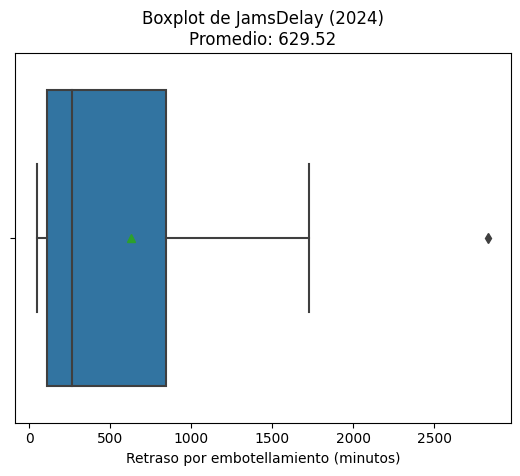

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, x='jams_delay', showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.xlabel('Retraso por embotellamiento (minutos)')
plt.show()


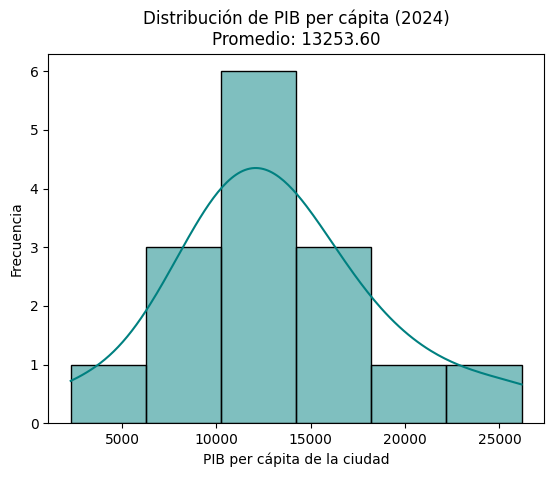

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_per_capita', kde=True, color='teal')

mean_gdp = merged['city_gdp_per_capita'].mean()
plt.title(f'Distribución de PIB per cápita (2024)\nPromedio: {mean_gdp:.2f}')
plt.xlabel('PIB per cápita de la ciudad')
plt.ylabel('Frecuencia')
plt.show()


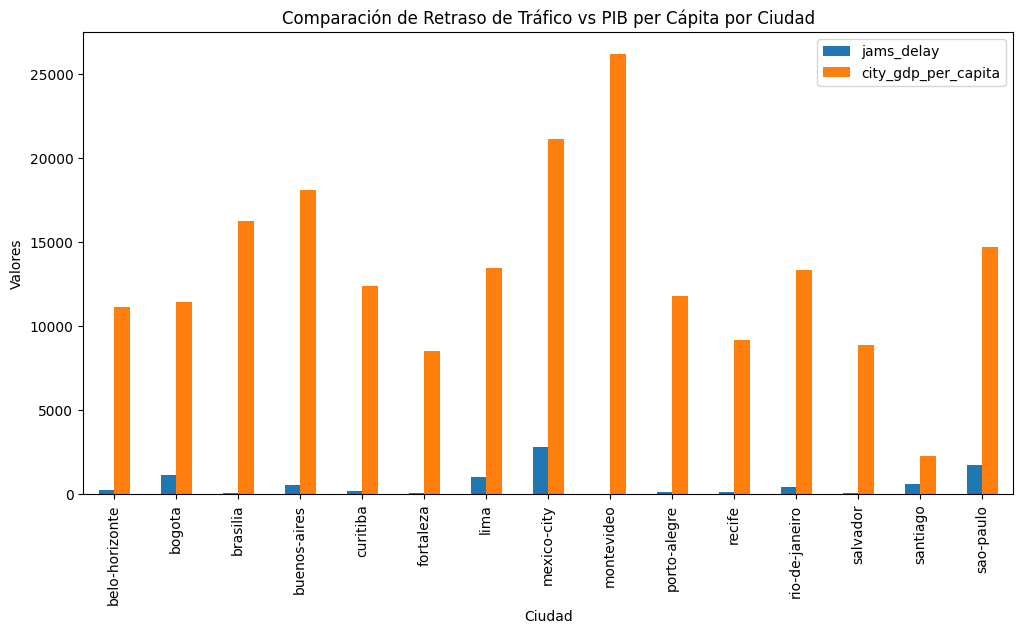

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot(kind='bar', x='city', y=['jams_delay', 'city_gdp_per_capita'], figsize=(12, 6))

plt.title('Comparación de Retraso de Tráfico vs PIB per Cápita por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Valores')
plt.xticks(rotation=90)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b>
Boxplot con <code>showmeans=True</code> ✅, histograma con <code>kde=True</code> y color personalizado ✅, barras con <code>kind='bar'</code>, <code>x='city'</code> y <code>rotation=90</code> ✅.
</div>

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión? No necesariamente. Las ciudades con el PIB per cápita más elevado suelen contar con una mejor infraestructura vial y de transporte público, lo que les permite mantener niveles de retraso (jams_delay) más bajos o moderados.

* ¿O sucede lo contrario, o no existe una relación clara? Sucede lo contrario en muchos casos: las ciudades con menor o mediano PIB per cápita (como varias megaciudades latinoamericanas) concentran los índices más altos de embotellamiento. Por lo tanto, no existe una relación directamente proporcional entre un PIB alto y una mayor congestión vehicular.

- Escribe tus comentarios: Relación entre economía y tráfico: No existe una correlación directa entre un mayor PIB per cápita y una mayor congestión vial. De hecho, varias ciudades con PIB per cápita medio o bajo presentan los mayores índices de retraso (`jams_delay`), mientras que ciudades con alto PIB per cápita logran mantener retrasos más moderados gracias a su infraestructura vial y de transporte público.
- Valores extremos (Outliers): En el gráfico de caja se observan valores atípicos en los niveles de congestión de ciertas ciudades (como Ciudad de México), que sobresalen significativamente de la mediana del resto de las metrópolis.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
La conclusión de fondo es correcta ("no existe correlación directa"). ✅ Dos ajustes de estilo:

<b>1. Lenguaje causal en la celda 38:</b> "las ciudades con PIB más elevado suelen contar con mejor infraestructura... lo que les permite mantener retrasos más bajos" asume causalidad. Para un análisis exploratorio usa: "se observa que", "los datos sugieren", "podría estar relacionado con".

<b>2. El ejemplo de celda 39 es impreciso:</b> "ciudades con PIB medio o bajo presentan los mayores índices de retraso" — pero Ciudad de México tiene uno de los PIBs más altos de la muestra (~USD 21,111) y aun así tiene la mayor congestión. Para ilustrar la ausencia de relación, Montevideo es mejor ejemplo: tiene el PIB más alto (~USD 26,176) y una de las congestiones más bajas (~50 min).
</div>


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.



# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b>
La celda 41 tiene código de exportación de CSV dentro de una celda Markdown — aparece como texto, no se ejecuta. El CSV sí fue exportado correctamente en la celda 42 (exec=55). Puedes eliminar la celda 41 para dejar el notebook más limpio.
</div>

In [ ]:
#Para poder ver o descargar el archivo generado:
#En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información.

merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)



---

## ✅ Entregables

1. **Notebook `.ipynb`** con todas las celdas (código + comentarios).
2. **CSV final**: `ladb_mobility_economy_2024_clean.csv`.
3. **Resumen ejecutivo breve** en Markdown (3–5 párrafos).


**Contexto & objetivo:**  
Este estudio analiza la relación entre la congestión vial (`jams_delay`, `travel_time_live_per_10kms_mins`) y la productividad económica (`city_gdp_per_capita`) en metrópolis clave. El objetivo es identificar si un mayor desarrollo económico mitiga la congestión y sustentar decisiones estratégicas de inversión en infraestructura de transporte público.


**Cobertura de datos:**  
El dataset consolidado incluye un total de **15 ciudades de Latinoamérica** evaluadas durante el periodo **2024**, asegurando datos homogéneos y representativos de la región.


**Metodología (alto nivel):**  
Se realizó la estandarización y renombrado de columnas, la conversión adecuada de fechas y el tratamiento de valores atípicos. Posteriormente, se aplicó una agregación por ciudad-año (`groupby`) y se integraron ambas fuentes de datos mediante un **INNER JOIN**. La calidad de los datos se validó mediante análisis exploratorio visual (diagramas de caja, histogramas con `kde=True` y gráficos de barras comparativos).


**Hallazgos iniciales:**  
No se observa una correlación directamente proporcional entre un PIB per cápita elevado y menores tiempos de congestión. Ciudades de la región con ingresos medios o bajos registran de forma persistente los mayores retrasos (`jams_delay`). Se identificaron valores atípicos severos en congestión, destacando la **Ciudad de México** como el punto crítico con mayor embotellamiento en la muestra.


**Recomendaciones**  

Se recomienda priorizar la inversión en infraestructura de transporte masivo en metrópolis con alto retraso vial como la **Ciudad de México** y **Bogotá**, donde el tráfico impacta directamente la eficiencia y productividad. Asimismo, se aconseja complementar futuros análisis integrando métricas de densidad poblacional y calidad del aire (`pm25`).

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 2)</b>
El resumen ejecutivo está completo y bien estructurado:
<ul>
<li>✅ Contexto: pregunta central, variables clave.</li>
<li>✅ Cobertura: 15 ciudades latinoamericanas, 2024.</li>
<li>✅ Metodología: renombrado, fechas, groupby, INNER JOIN, visualizaciones.</li>
<li>✅ Hallazgos: sin correlación directa, CDMX como outlier crítico.</li>
<li>✅ Recomendaciones: CDMX y Bogotá como candidatas, sugerencia de ampliar análisis con densidad y pm25.</li>
</ul>
</div>

<div class="alert alert-block alert-info">
<b>Comentario final del revisor. (Iteración 2)</b>
<b>Resumen de la revisión (Iteración 2):</b>

✅ <b>Único bloqueante resuelto:</b> resumen ejecutivo con las cuatro secciones y contenido propio.

✅ <b>Todo el pipeline verificado:</b> renombrado (12+7 cols), GDP=18117.0, fechas, filtros, groupby, merge con 15 ciudades, boxplot showmeans, histograma kde, barras rotation=90, CSV exportado.

🟡 <b>Dos observaciones de estilo (no bloquean):</b>
<ul>
<li>En Hallazgos: "ciudades con ingresos medios o bajos registran los mayores retrasos" — CDMX tiene un PIB relativamente alto (~USD 21,111) y es el mayor outlier en congestión, lo que contradice esa afirmación. La conclusión correcta es que <b>no hay relación lineal clara en ninguna dirección</b> (ni más PIB → menos congestión, ni menos PIB → más congestión).</li>
<li>En Recomendaciones: "el tráfico impacta directamente la eficiencia" usa lenguaje causal. En un análisis exploratorio es más preciso: "se observa una asociación entre..." o "sugiere que...".</li>
</ul>

🔴 <b>Puntos bloqueantes:</b> ninguno.

<b>Decisión: proyecto aprobado ✅.</b>

Alan, dos iteraciones con un único ajuste — y el pipeline técnico estaba muy bien desde la primera entrega. El resumen cierra el trabajo de forma sólida. ¡Felicitaciones y mucho éxito en los próximos sprints! 🚀
</div>